<table style="border-collapse: collapse; border: none;">
  <tr>
    <td style="vertical-align: top; border: none;">
      <img src="https://i.imgur.com/x6poGzn.png" width="130" height="170" alt="Colaboratory logo" style="margin-right: 10px;">
    </td>
    <td style="border: none;">
      <h1 style="margin-bottom: 0;"><b>Laboratorio 7: Transformada rápida de Fourier (FFT).</b></h1>
      <hr style="margin-top: 5px; margin-bottom: 5px;">
      <div style="font-size: 20px; text-align: left;">
        Física computacional 1.<br>
      </div>
      <div style="font-size: 20px; text-align: left;">
        Nevis Saray Pérez Herrera<br>
      </div>
      <div style="font-size: 13px; text-align: left;">
      <br>Universidad de Antioquia, Instituto de Física<br>
      Mayo de 2026.
      </div>
    </td>
  </tr>
</table>

# Transformada rápida de Fourier 
### 1. Realiza la FFT usando las rutinas de SciPy y NumPy.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

In [3]:
signal, fs= librosa.load("Nota_CM_piano.mp3", sr=None)
print("Frecuencia de muestreo:", fs)
print("Tamaño de la señal:", signal.shape)

Frecuencia de muestreo: 44100
Tamaño de la señal: (152064,)


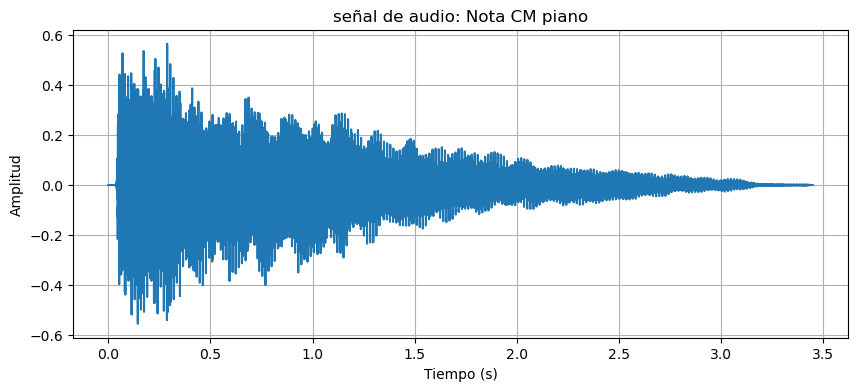

In [4]:
#grafica de la señal en el tiempo.
t = np.arange(len(signal)) / fs
plt.figure(figsize =(10,4))
plt.plot(t, signal)
plt.title("señal de audio: Nota CM piano")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

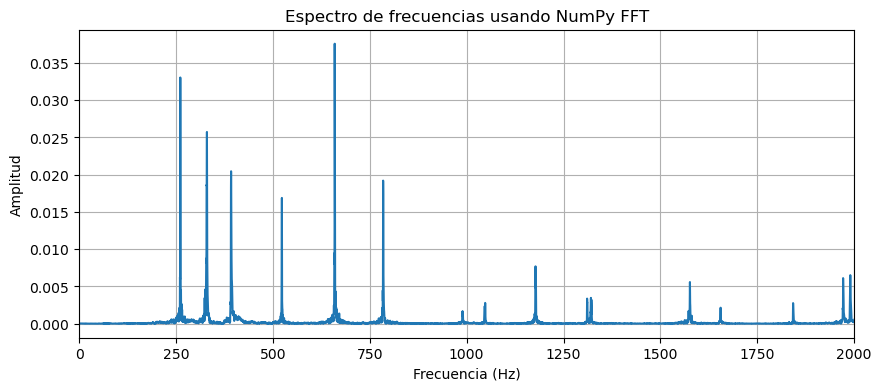

In [5]:
#FFT con Numpy
N=len(signal)
Y_np = np.fft.fft(signal) #aqui se hace la FFT con Numpy
freq_np = np.fft.fftfreq(N, d=1/fs) #las frecuencias
freq_positive_np = freq_np[:N//2]
amp_positive_np = 2/N*np.abs(Y_np[:N//2])

plt.figure(figsize=(10, 4))
plt.plot(freq_positive_np, amp_positive_np)
plt.title("Espectro de frecuencias usando NumPy FFT")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0, 2000)
plt.grid()
plt.show()

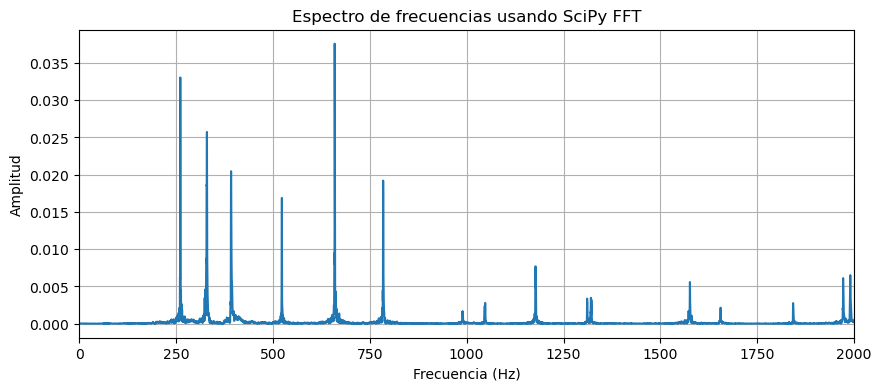

In [6]:
#FFT usando SciPy
Y_sp = fft(signal) #FFT con SciPy
freq_sp = fftfreq(N, d=1/fs)

#otra vez tomamos solo las vfrecuencias positivas 
freq_positive_sp = freq_sp[:N//2]
amp_positive_sp = 2/N*np.abs(Y_sp[:N//2])

plt.figure(figsize=(10, 4))
plt.plot(freq_positive_sp, amp_positive_sp)
plt.title("Espectro de frecuencias usando SciPy FFT")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0, 2000)
plt.grid()
plt.show()

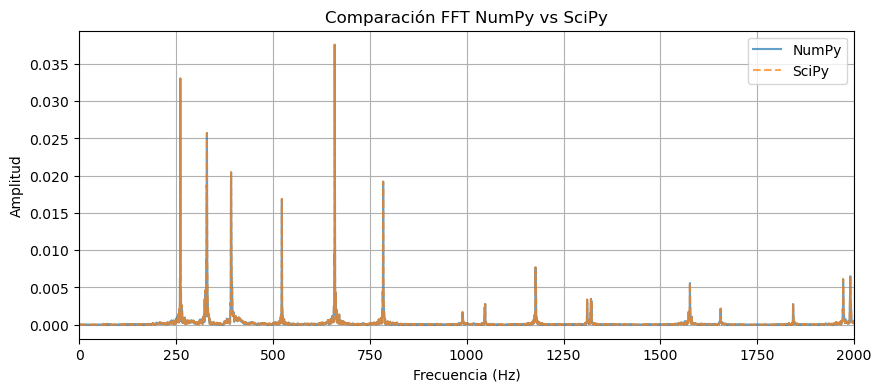

In [7]:
#comparemos el resultado de ambas librerias:

plt.figure(figsize=(10, 4))
plt.plot(freq_positive_np, amp_positive_np, label="NumPy", alpha=0.7)
plt.plot(freq_positive_sp, amp_positive_sp, "--", label="SciPy", alpha=0.7)
plt.title("Comparación FFT NumPy vs SciPy")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0, 2000)
plt.legend()
plt.grid()
plt.show()

En ambas librerías nos quedamos con la parte positiva de la señal debido a que la señal de audio es una señal real por lo tanto cuando aplicamos FFT esta nos queda simétrica, lo que significa que las frecuencias negativas son la mismas que las positivas pero reflejadas y conjugadas. 

Los resultados obtenidos por ambas librerías son prácticamente iguales no hay diferencias marcadas y eso se puede observar en la superposición de las gráficas. 

También podemos encontrar las frecuencias dominantes. 

In [8]:
peaks, properties = find_peaks(amp_positive_sp, height = np.max(amp_positive_sp)*0.05) #buscamos picos que su altura sea al menos el 5% del pico más alto
peak_freqs = freq_positive_sp[peaks]
peak_amps = amp_positive_sp[peaks]
df_peaks = pd.DataFrame({
    "Frecuecnia (Hz)" : peak_freqs,
    "Amplitud": peak_amps
})
df_peaks = df_peaks.sort_values("Amplitud", ascending=False)
df_peaks.head(10)

,Frecuecnia (Hz),Amplitud
18,659.481534,0.037576
3,261.008523,0.033041
12,329.740767,0.025733
14,392.092803,0.020458
24,784.475616,0.019204
11,328.870739,0.018629
15,523.177083,0.016880
17,658.611506,0.009466
10,328.000710,0.008748
27,1177.728456,0.007699


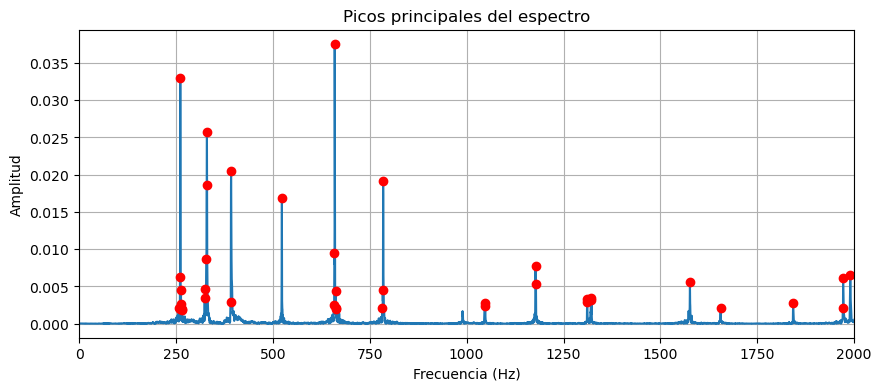

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(freq_positive_sp, amp_positive_sp)
plt.plot(peak_freqs, peak_amps, "ro")
plt.title("Picos principales del espectro")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0, 2000)
plt.grid()
plt.show()

### 2. Usa la rutina creada en clase FT(x, y). Modifícala y realiza la FT a la señal. ¿Obtienes los mismos resultados?

En las notas tenemos que la transformada de Fourier es: $$ F(w) = \frac{1}{\sqrt{2\pi}} \int_{\infty} f(t)e^{-2i\pi \omega}dt $$

Esto también lo podemos esccrbir como: $$ F(f) = \int y(t)e^{-2\pi ift} dt $$ y aparte como lo que tenemos en un audio aqui nosotros no tenemos una función continua $y(t)$ por lo  tanto aproximamos la integral como unsa suma de rectángulos. 

$$ F(f) \approx \sum{y(t_n)e^{-2 \pi ift_n}} \Delta t $$

In [ ]:
"""
Calculamos una transformada de Fourier aproximada usando suma discreta.
    
t: arreglo de tiempos
y: señal de audio
f_values: frecuencias donde se evalúa la transformada
"""

def FT_audio(t, y, f_values): 
    dt= t[1]- t[0]
    resultados = []
    
    for f in f_values:
        F= np.sum(y*np.exp(-1j*2*np.pi*f*t))*dt
        amp=np.abs(F)
        real=F.real
        imag=F.imag
        ang=np.arctan2(imag, real)
        
        resultados.append([f,real,imag,amp,ang])
        
    df= pd.DataFrame(resultados,columns=["f","ReF","ImF","AMP","ANG"])
    
    return df

# Tomamos un fragmento de la señal para que la FT manual sea más rápida
duracion= 2  # segundos
M =int(duracion*fs)

signal_short=signal[:M]
t_short=t[:M]

f_values= np.linspace(0, 2000, 1000)
df_ft = FT_audio(t_short, signal_short, f_values)
df_ft.head()

,f,ReF,ImF,AMP,ANG
0,0.000000,-0.000099,0.000000,0.000099,3.141593
1,2.002002,0.000007,0.000033,0.000033,1.351225
2,4.004004,-0.000011,0.000035,0.000036,1.868954
3,6.006006,0.000029,0.000023,0.000037,0.679336
4,8.008008,0.000057,0.000004,0.000057,0.070386


f es la frecuencia donde estoy evaluando la TF, ReF es la parte real de esa  frecuencia y representa una parte de la contribución de esa frecuencia (la parte asociada al coseno), ImF es la parte imaginaria de esa frecuencia  y también representa una parte de la contribución de esa frecuencia (La parte asociada al seno), AMP es la amplitud o magnitud de la transformada y nos dice con que intensidad aparece esa frecuencia en la señal, en la tabla podemos ver que son muy pequeños por lo que podemos decir que estas frecuencias casi no estan presentes en el audio, ANG es el ángulo esta nos indica el desfase temporal de esa frecuencia, es decir, en que parte del ciclo empieza la onda.

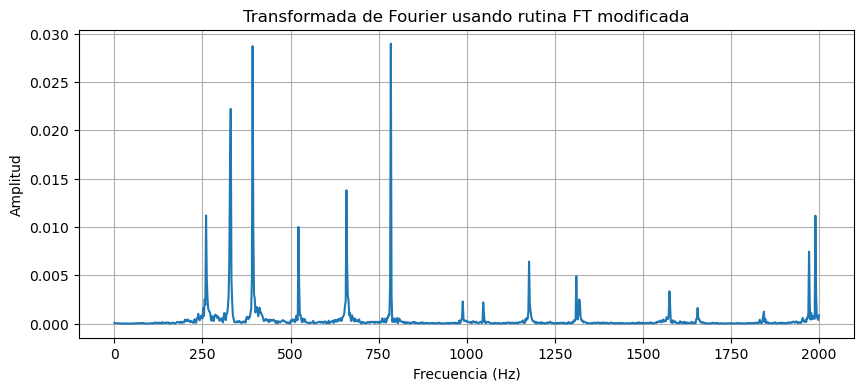

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df_ft["f"], df_ft["AMP"])
plt.title("Transformada de Fourier usando rutina FT modificada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

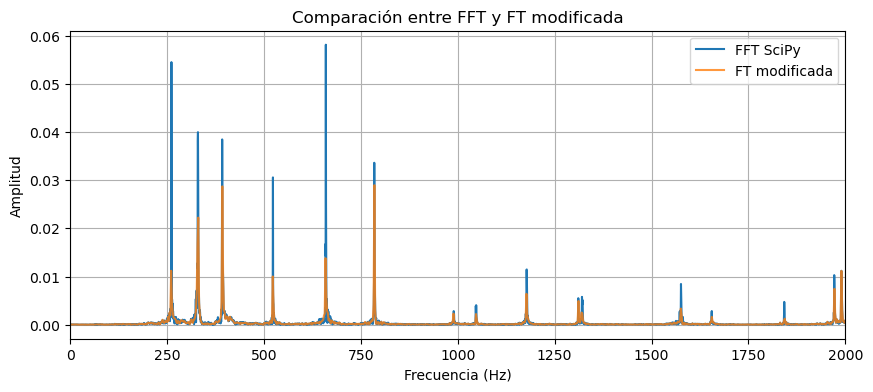

In [ ]:
#Ahora comparamos la FFT con la FT
N_short= len(signal_short)
Y_short= fft(signal_short)
freq_short= fftfreq(N_short, d=1/fs)

freq_short_positive= freq_short[:N_short//2]
amp_short_positive= 2/N_short*np.abs(Y_short[:N_short//2])

plt.figure(figsize=(10, 4))
plt.plot(freq_short_positive, amp_short_positive, label="FFT SciPy")
plt.plot(df_ft["f"], df_ft["AMP"], label="FT modificada", alpha=0.8)
plt.title("Comparación entre FFT y FT modificada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0, 2000)
plt.legend()
plt.grid()
plt.show()

Al aplicar la Transformada Rápida de Fourier mediante las rutinas de NumPy y SciPy se obtiene el espectro de frecuencias de la señal de audio correspondiente al acorde de Do mayor. Los resultados obtenidos con NumPy y SciPy son equivalentes, debido a que ambas librerías implementan el algoritmo FFT para calcular la Transformada Discreta de Fourier.

Por otra parte, al modificar la rutina FT(x, y) vista en clase para trabajar con datos discretos de audio, se obtiene un resultado cualitativamente similar al de la FFT. Sin embargo, la rutina manual es mucho más lenta, ya que calcula la transformada frecuencia por frecuencia mediante sumas directas. La FFT, en cambio, calcula todo el espectro de forma mucho más eficiente.

Al comparar FFT de scipy (que da básicamente los mismos resultados que Numpy) se observa que ambos métodos identifican las mismas frecuencias dominantes de la señal. Aunque las amplitudes no coinciden exactamente (esto puede ser debido a diferencias de normalización entre ambos métodos) las posiciones de los picos son similares, por lo tanto, el método FT reproduce cualitativamente los resultados obtenidos con la FFT.  

En conclusión, ambos métodos permiten identificar las frecuencias presentes en la señal, pero la FFT es el método más conveniente para analizar señales de audio reales.